In [2]:
import torch
import os
import sys

sys .path.append(os.path.abspath(".."))
from models.tgcn_model import TGCNModel
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt


df= pd.read_hdf("../data/METR-LA.h5")
data = (df.values-df.values.mean())/df.values.std()

train_losses = np.load("../checkpoints/train_losses_gcn128_lr0.001.npy")
print ("Num of epochs: ", len(train_losses))

Num of epochs:  1500


In [3]:
N = 207
seq_len = 12
pred_len = 3

A_norm = torch.load("../data/adj_norm_METR_LA.pt")

model = TGCNModel(
    num_nodes=N,
    in_feat=1,
    gcn_hidden=64,
    seq_len=seq_len,
    pred_len=pred_len,
    A_norm=A_norm
)

model.load_state_dict(
    torch.load("../checkpoints/tgcn_gcn64_lr0.001.pth", map_location="cpu")
)

model.eval()

TGCNModel(
  (gcn1): GCNLayer(
    (linear): Linear(in_features=1, out_features=64, bias=True)
  )
  (gcn2): GCNLayer(
    (linear): Linear(in_features=64, out_features=64, bias=True)
  )
  (gru): GRU(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

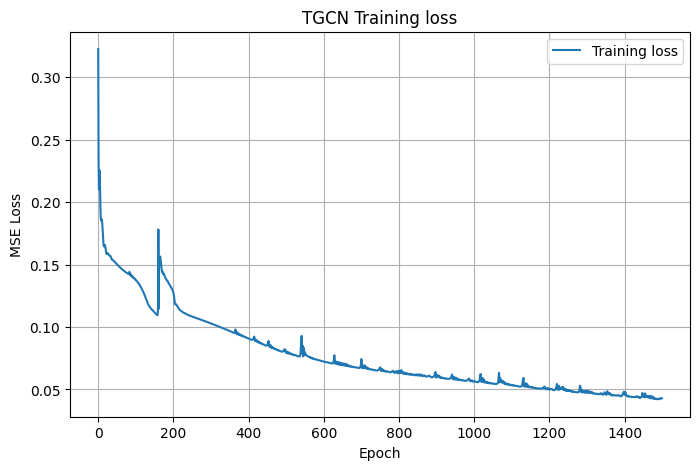

In [4]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label= "Training loss")
plt.xlabel ("Epoch")
plt.ylabel ("MSE Loss")
plt.title("TGCN Training loss")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
t=1000

X_test = data [t : t+seq_len]
y_true = data [t + seq_len : t +seq_len +pred_len]

X_test = torch.tensor(X_test).unsqueeze(0).float()
y_true = torch.tensor(y_true).float()

with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.squeeze(0)

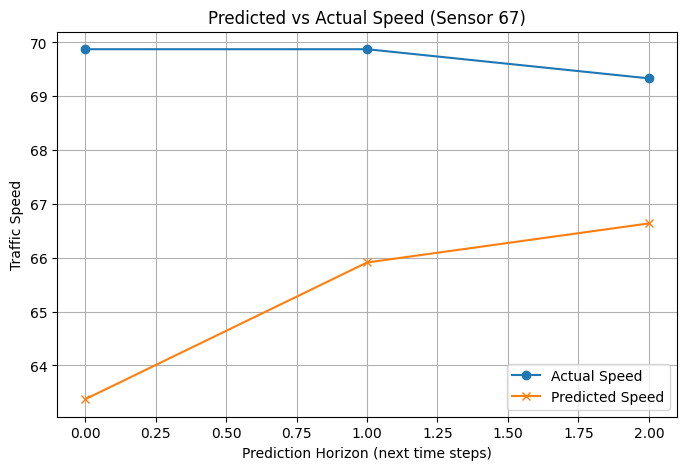

In [6]:
y_true_kmph = y_true* df.values.std() + df.values.mean()
y_pred_kmph = y_pred* df.values.std() + df.values.mean()

sensor_id = 67   # any sensor index

plt.figure(figsize=(8,5))
plt.plot(y_true_kmph[:, sensor_id], marker="o", label="Actual Speed")
plt.plot(y_pred_kmph[:, sensor_id], marker="x", label="Predicted Speed")

plt.xlabel("Prediction Horizon (next time steps)")
plt.ylabel("Traffic Speed")
plt.title(f"Predicted vs Actual Speed (Sensor {sensor_id})")
plt.legend()
plt.grid(True)
plt.show()

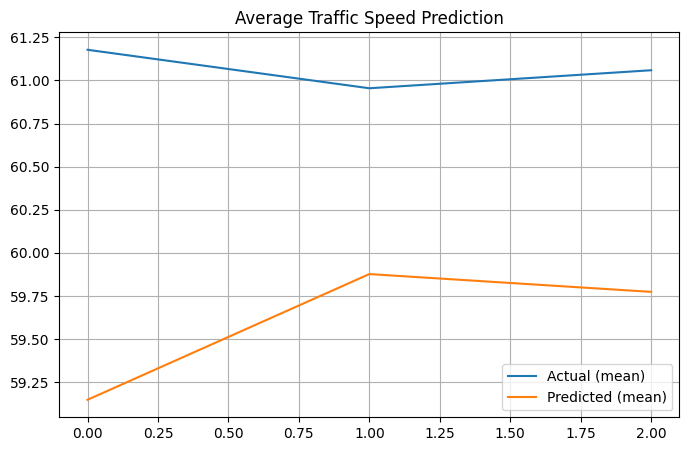

In [7]:
plt.figure(figsize=(8,5))
plt.plot(y_true_kmph.mean(axis=1), label="Actual (mean)")
plt.plot(y_pred_kmph.mean(axis=1), label="Predicted (mean)")
plt.legend()
plt.title("Average Traffic Speed Prediction")
plt.grid(True)
plt.show()

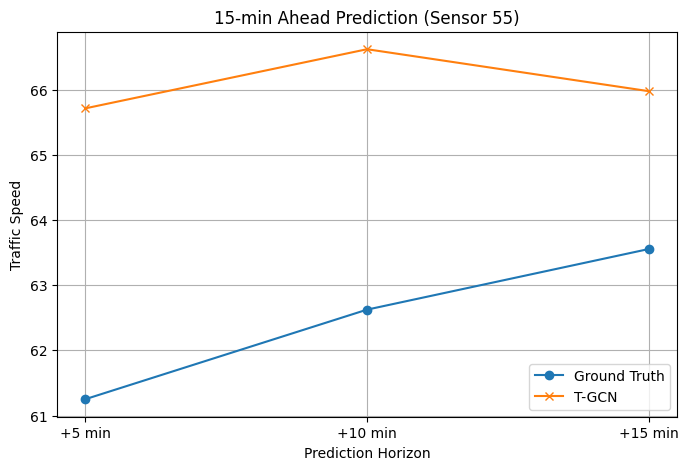

In [8]:
sensor_id = 55

plt.figure(figsize=(8,5))
plt.plot(y_true_kmph[:, sensor_id], marker="o", label="Ground Truth")
plt.plot(y_pred_kmph[:, sensor_id], marker="x", label="T-GCN")
plt.xticks([0,1,2], ["+5 min", "+10 min", "+15 min"])
plt.xlabel("Prediction Horizon")
plt.ylabel("Traffic Speed")
plt.title("15-min Ahead Prediction (Sensor 55)")
plt.legend()
plt.grid(True)
plt.show()

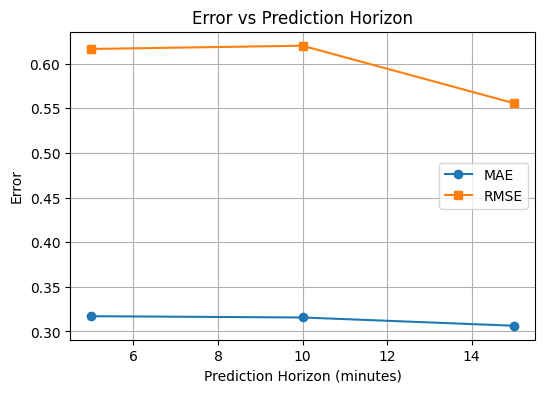

In [9]:
mae_per_horizon = []
rmse_per_horizon = []

for h in range(y_pred.shape[0]):
    err = y_true[h] - y_pred[h]
    mae_per_horizon.append(torch.mean(torch.abs(err)).item())
    rmse_per_horizon.append(torch.sqrt(torch.mean(err**2)).item())

plt.figure(figsize=(6,4))
plt.plot([5,10,15], mae_per_horizon, marker='o', label="MAE")
plt.plot([5,10,15], rmse_per_horizon, marker='s', label="RMSE")
plt.xlabel("Prediction Horizon (minutes)")
plt.ylabel("Error")
plt.title("Error vs Prediction Horizon")
plt.legend()
plt.grid(True)
plt.show()

Best sensor: 106
Worst sensor: 166


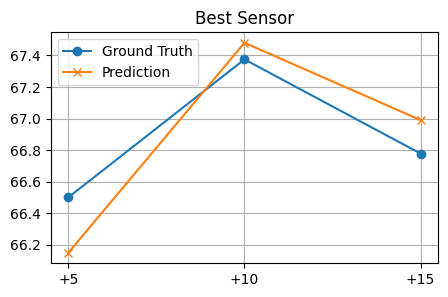

In [10]:
sensor_mae = torch.mean(torch.abs(y_true - y_pred), dim=0)

best_sensor = torch.argmin(sensor_mae).item()
worst_sensor = torch.argmax(sensor_mae).item()

print("Best sensor:", best_sensor)
print("Worst sensor:", worst_sensor)

for s, title in [(best_sensor, "Best Sensor")]:
    plt.figure(figsize=(5,3))
    plt.plot(y_true_kmph[:, s], marker="o", label="Ground Truth")
    plt.plot(y_pred_kmph[:, s], marker="x", label="Prediction")
    plt.xticks([0,1,2], ["+5","+10","+15"])
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:

# MAE
mae = torch.mean(torch.abs(y_true_kmph.mean(axis=1) - y_pred_kmph.mean(axis=1)))

# RMSE
rmse = torch.sqrt(torch.mean((y_true_kmph.mean(axis=1) - y_pred_kmph.mean(axis=1)) ** 2))

# MAPE
mape = torch.mean(torch.abs((y_true_kmph.mean() - y_pred_kmph.mean()) / (y_true_kmph.mean()))) * 100

print(f"MAE  : {mae.item():.3f}")
print(f"RMSE : {rmse.item():.3f}")
print(f"MAPE : {mape.item():.2f}%")

MAE  : 1.463
RMSE : 1.519
MAPE : 2.40%


In [12]:
# sensor 767542 to 767541 distance is 1489.3m 
# sensor 767541 and 767542 are at index 1 and 2 repectively in the list
# actually it's not kmph it is miles per hour 
# 1 mile = 1609.34 m 

dist = 1489.3 / 1609.34
speed =  (y_pred_kmph[0,2])
eta = dist / speed
print (eta*60) # in min
print (speed)

tensor(0.8402)
tensor(66.0816)


In [13]:
dists = pd.read_csv("../data/distances_la_2012.csv")

pairs = [
     (767542, 767541),
    (767542, 717447),
    (767541, 717447),

    (717458, 773024),
    (767542, 767466),
    (717447, 717458),
    (716339 , 717462),
    (767542,773024),
    (717458, 717462),
    (773024, 716331),
    (716339, 716310),
    (773024, 716310),(717087, 717089), (717089,737502),
    (716310,773024)


]

for u, v in pairs:
    row = dists[(dists["from"] == u) & (dists["to"] == v)]
    if len(row) == 0:
        print(f"{u} -> {v} : NOT FOUND")
    else:
        print(f"{u} -> {v} : {row.iloc[0]['cost']} meters")

767542 -> 767541 : 1489.3 meters
767542 -> 717447 : 6971.3 meters
767541 -> 717447 : 8563.8 meters
717458 -> 773024 : 5837.5 meters
767542 -> 767466 : NOT FOUND
717447 -> 717458 : 5554.8 meters
716339 -> 717462 : 6329.7 meters
767542 -> 773024 : 8305.8 meters
717458 -> 717462 : 5419.3 meters
773024 -> 716331 : 4533.1 meters
716339 -> 716310 : NOT FOUND
773024 -> 716310 : NOT FOUND
717087 -> 717089 : 2618.8 meters
717089 -> 737502 : NOT FOUND
716310 -> 773024 : NOT FOUND


In [14]:
#calculate eta from 767542 to 773024

dist = 8305.8 / 1609.34 

if (dist / y_pred_kmph[0,2] < 5/60):
    eta = dist / y_pred_kmph[0,2]
elif ((dist - (y_pred_kmph[0,2])/12) / y_pred_kmph[1,2] < 5/60):
    eta = 5 + dist -((y_pred_kmph[0,2])/12) / y_pred_kmph[1,2]
print (eta*60)

tensor(4.6860)


In [15]:
dist_df = pd.read_csv("../data/distances_la_2012.csv")

def get_distance_km(u, v):
   
    row = dist_df[(dist_df["from"] == u) & (dist_df["to"] == v)]
    
    if len(row) == 0:
        raise ValueError(f"Distance not found for {u} -> {v}")
    
    meters = row.iloc[0]["cost"]
    print (meters / 1609.34)
    return meters / 1609.34  # miles

def get_speed_kmph(y_pred_kmph, t, sensor_idx):
    return float(y_pred_kmph[t, sensor_idx])

df = pd.read_hdf("../data/METR-LA.h5")

df.columns = df.columns.astype(int)
sensor_ids = df.columns.tolist()

sensor_to_idx = {sid: i for i, sid in enumerate(sensor_ids)}

print("Example mapping:", list(sensor_to_idx.items())[:5])



Example mapping: [(773869, 0), (767541, 1), (767542, 2), (717447, 3), (717446, 4)]


In [16]:
def ETA (u, v, y_pred_kmph, sensor_idx, horizon_min=5):
    dist_left = get_distance_km(u, v)
    total_time = 0.0

    for t in range(y_pred_kmph.shape[0]):
        speed = get_speed_kmph(y_pred_kmph, t, sensor_idx)

        if speed <= 0:
            return float("inf")

        max_dist = speed * (horizon_min / 60)

        if dist_left <= max_dist:
            total_time += (dist_left / speed) * 60
            return total_time
        else:
            dist_left -= max_dist
            total_time += horizon_min

    return total_time

eta = ETA(u=767542, v=773024, y_pred_kmph=y_pred_kmph, sensor_idx=2)

print(f"ETA (piecewise): {eta:.2f} minutes")



5.160997676065965
ETA (piecewise): 4.69 minutes


In [17]:
import heapq

def edge_time_minutes(u, v, y_pred_kmph, sensor_to_idx, horizon=0):
   
    if u not in sensor_to_idx :
        return None
    row = dist_df[(dist_df["from"] == u) & (dist_df["to"] == v)]
    if len(row) == 0:
        return None  # edge doesn't exist

    dist_miles = row.iloc[0]["cost"] / 1609.34
    speed = y_pred_kmph[horizon, sensor_to_idx[u]]

    return (dist_miles / speed) * 60


def dijkstra_eta(start, end, y_pred_kmph, sensor_to_idx):
    pq = [(0, start)]  # (time, node)
    best_time = {start: 0}
    parent = {start: None}

    while pq:
        curr_time, u = heapq.heappop(pq)

        if u == end:
            break

        for _, row in dist_df[dist_df["from"] == u].iterrows():
            v = row["to"]

            t = edge_time_minutes(u, v, y_pred_kmph, sensor_to_idx)
            if t is None:
                continue

            new_time = curr_time + t

            if v not in best_time or new_time < best_time[v]:
                best_time[v] = new_time
                parent[v] = u
                heapq.heappush(pq, (new_time, v))

    # reconstruct path
    path = []
    node = end
    while node is not None:
        path.append(node)
        node = parent.get(node)

    path.reverse()
    return best_time.get(end, None), path



In [18]:
start = 717447
end   = 717458

eta, path = dijkstra_eta( start, end, y_pred_kmph, sensor_to_idx)


print("Path:", path)
print(f"ETA: {eta:.3f} minutes")


Path: [717447, 717452.0, 716337.0, 717458]
ETA: 3.690 minutes


In [19]:

locs = pd.read_csv("../data/graph_sensor_locations.csv")

coord = {
    row["sensor_id"]: (row["latitude"], row["longitude"])
    for _, row in locs.iterrows()
}

route_coords = [coord[s] for s in path]

import folium

m = folium.Map(location=route_coords[0], zoom_start=15)

folium.PolyLine(route_coords, color="blue",weight=5, opacity=0.8).add_to(m)

for s in path:
    folium.CircleMarker( location=coord[s], radius=6, popup=str(s), color="red", fill=True).add_to(m)

m

